# Tarea N.5 Metodos de solucion numerica para Ecuaciones  Diferenciales Ordinarias

**Arenas Limon Angel Daniel**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Constante de desplazamiento de Wien.

La ley de radiacion de Planck nos dice que la intensidad de la radiacion por unidad de area y unidad de longitud de onda $\lambda$ de un cuerpo negro a la temperatura T es

\begin{align}
    I(\lambda)= \frac{2 \pi hc^2 \lambda^{-5}}{e^{\frac{hc}{\lambda kbT}}-1}
\end{align}

donde $h$ es la constante de Planck, $c$ es la velocidad de la luz y $k_B$ es la constante de Boltzmann.

**a)** Demuestra diferenciando (derivando) que la longitud de onda λ a la que la radiacion emitida alcanza su mayor intensidad, es la solucion de la ecuacion 

\begin{align}
    5e^{\frac{-hc}{\lambda k_B T}} + \frac{hc}{\lambda k_B T} - 5 = 0
\end{align}

Sustituye $x = \displaystyle{\frac{hc}{\lambda k_B T}}$ y demuestra que la longitud de onda de la radiacion ́
maxima obedece al  ́ desplazamiento de Wienley:

\begin{align} 
    \lambda = \frac{b}{T}
\end{align}

donde la llamada constante de desplazamiento de Wien es $b = hc/k_Bx$, y $x$ es la solucion de la ecuacion no lineal

\begin{align} 
    5e^{−x} + x − 5 = 0.
\end{align}

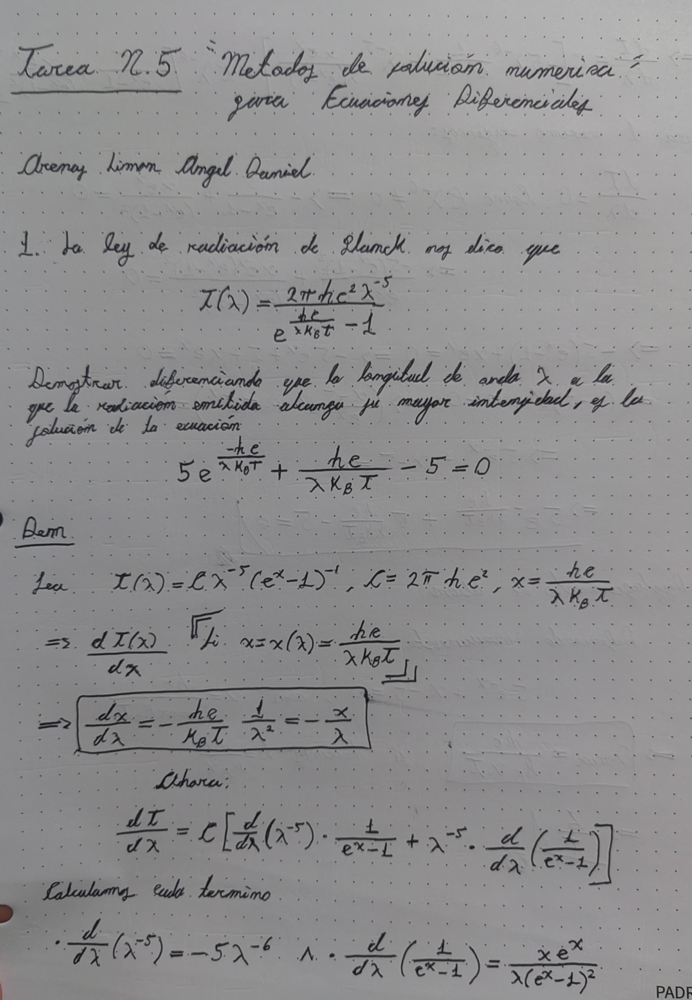

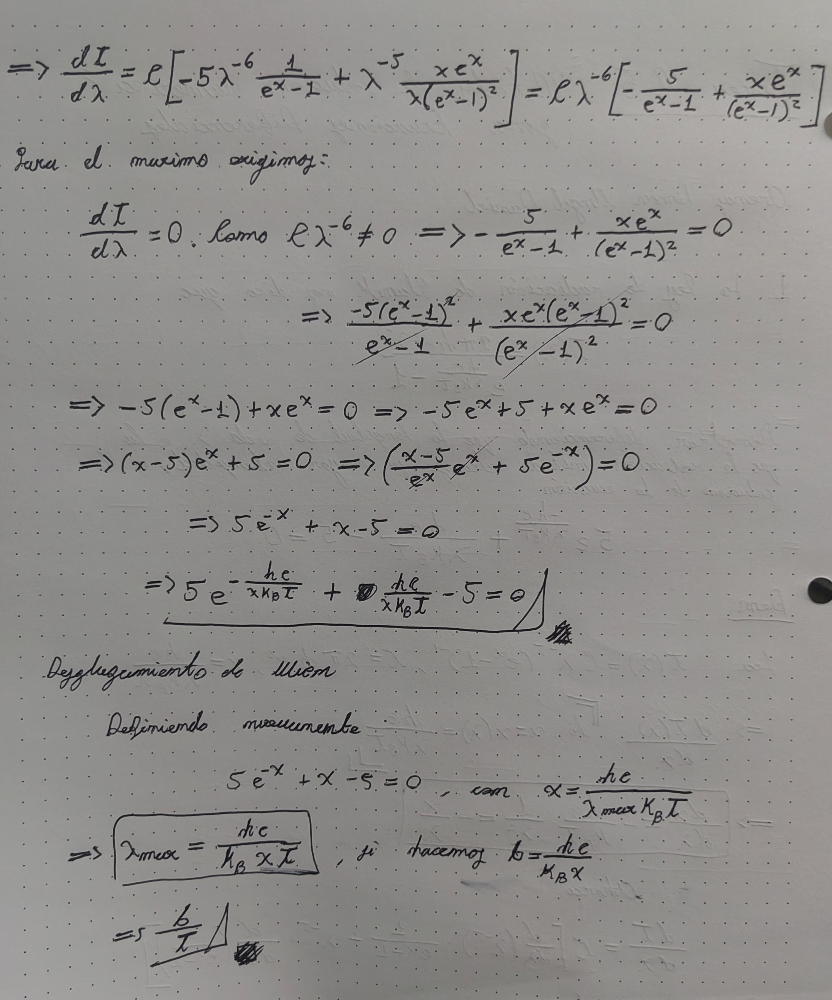

**b)** Escribe un programa para resolver esta ecuacion con una precision ($\epsilon$xactitud) de $\epsilon = 10^{−6}$ usando el metodo de busqueda binaria y ası, encuentra un valor para la constante de desplazamiento.

In [10]:
h = 6.62607015e-34      # Constante de Planck 
c = 2.99792458e8        # Velocidad de la luz 
kB = 1.380649e-23       # Constante de Boltzmann 

# Definimos la función f(x)
def f(x):
    return 5 * np.exp(-x) + x - 5

# Intervalo inicial donde sabemos que hay raíz
x1 = 4.0
x2 = 6.0
error = 1.0
epsilon = 1e-6

while error > epsilon:
    y1 = f(x1)
    y2 = f(x2)

    s1 = np.sign(y1)
    s2 = np.sign(y2)

    if s1 == s2:
        print("Elige otros valores para x1 y x2")
        break
    else:
        x = (x1 + x2) / 2
        s = np.sign(f(x))

        if s == s1:
            x1 = x
        else:
            x2 = x

    error = abs(x2 - x1)

# Solución para x
x_sol = (x1 + x2) / 2
print(f"Solución x = {x_sol:.6f}")

# Constante de desplazamiento de Wien
b = (h * c) / (kB * x_sol)
print(f"Constante de Wien b = {b:.9e} m·K")


Solución x = 4.965114
Constante de Wien b = 2.897772022e-03 m·K


**c)** La ley de desplazamiento es la base del metodo de pirometrıa optica, un metodo para medir las temperaturas de los objetos observando el color de la radiacion termica que emiten. El metodo se utiliza habitualmente para estimar las temperaturas superficiales de cuerpos astronomicos, como el Sol. El pico de longitud de onda en la radiacion emitida por el Sol cae en λ = 502 nm. A partir de las ecuaciones anteriores y el valor de la constante de desplazamiento, estima la temperatura de la superficie del Sol.

In [24]:
if f(x1)*f(x2) > 0:
    raise ValueError("Intervalo inicial no garantiza cambio de signo.")

iter_count = 0
while abs(x2 - x1) > epsilon:
    xm = 0.5*(x1 + x2)
    if f(x1)*f(xm) <= 0:
        x2 = xm
    else:
        x1 = xm
    iter_count += 1

x_sol = 0.5*(x1 + x2)

# Constante de Wien y temperatura del Sol
b = h*c/(kB*x_sol)           # m*K
lambda_sun = 502e-9          # m (502 nm)
T_sun = b / lambda_sun       # K

# También calculamos usando el valor tabulado de b para comparación
b_tab = 2.897771955e-3       # m*K (valor tabulado aproximado)
T_tab = b_tab / lambda_sun

x_sol, b, T_sun, iter_count, b_tab, T_tab

(4.965114116668701,
 0.0028977720223463226,
 5772.454227781519,
 0,
 0.002897771955,
 5772.454093625498)

## 2. El punto de Lagrange. 

Hay un punto magico entre la Tierra y la Luna, llamado punto de Lagrange $L_1$, en el cual un satelite orbitar  a la Tierra en perfecta sincronıa con la Luna, permaneciendo siempre entre las dos. Esto funciona porque la atraccion de la Tierra hacia adentro y la atraccion de la Luna hacia afuera se combinan para crear exactamente la fuerza centrıpeta necesaria para mantener al satelite en esa orbita. Esta es la configuracion:

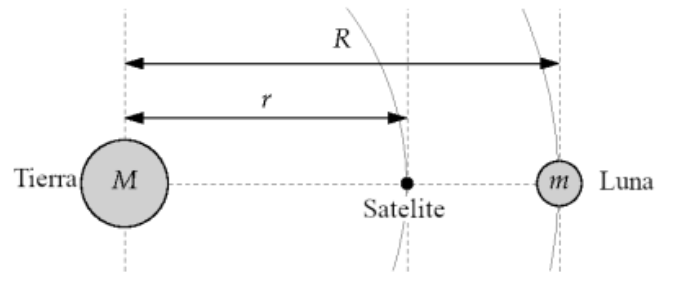

**a)** Suponiendo que las orbitas son circulares y que la Tierra es mucho mas masiva que la Luna o el satelite, demuestra que la distancia $r$ desde el centro de la Tierra hasta el punto $L_1$ satisface:

\begin{align}
    \frac{GM}{r^2} - \frac{Gm}{(R - r)^2} = \omega^2 r,
\end{align}

donde $M$ y $m$ son las masas de la Tierra y la Luna, $G$ es la constante gravitacional de Newton y $ω$ es la velocidad angular tanto de la Luna como del satelite.

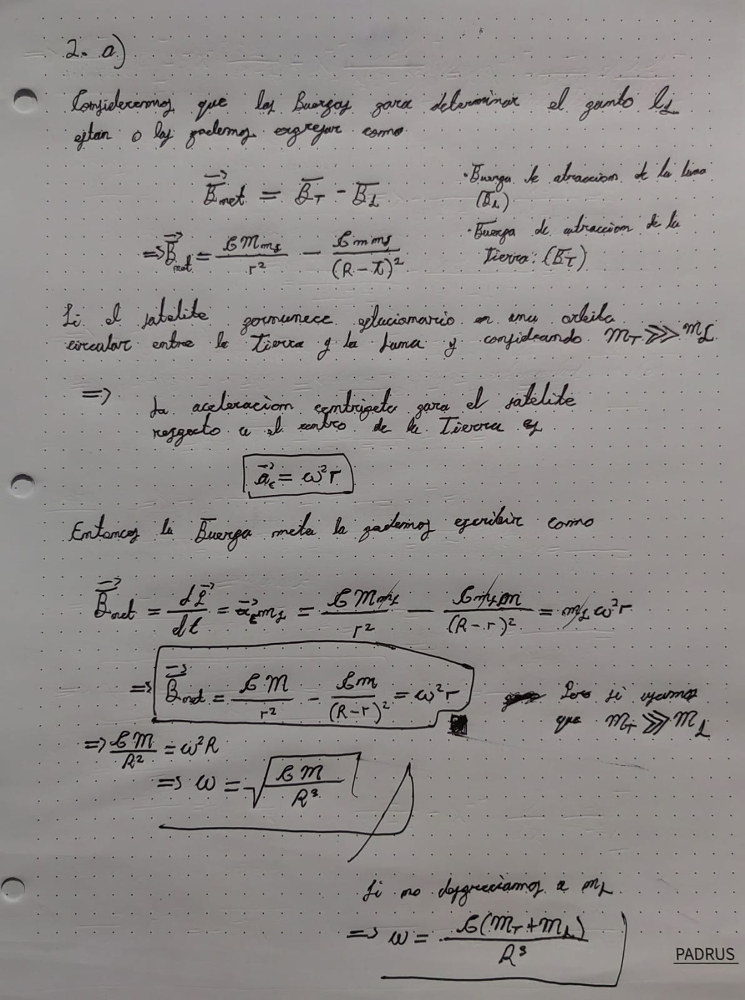

**b)** La ecuacion anterior es una ecuacion polinomica de quinto orden en  $r$. Estas ecuaciones no se pueden resolver exactamente de forma cerrada, pero es sencillo resolverlas numericamente. Escribe un programa que utilice el metodo de Newton para resolver la distancia $r$ desde la Tierra hasta el punto $L_1$. Calcula una solucion con una precision ($\epsilon$xactitud) de al menos cuatro cifras significativas.

Los valores de los distintos parametros son:  ́

\begin{align}
    G &= 6.674 × 10^{−11} m^3 kg^{−1}s^{−2}\\
    M &= 5.974 × 10^{24} kg\\
    m &= 7.348 × 10^{22} kg\\
    R &= 3.844 × 10^8 m\\
    \omega &= 2.662 × 10^{-6}s^{−1}
\end{align}

Considera que deberas elegir un valor inicial adecuado para  r.

In [31]:
#Definimos constantes a utulizar
G = 6.674e-11
M = 5.974e24
m = 7.348e22
R = 3.844e8
omega = 2.662e-6


#definimos la funcion de newton de la clase
def NewtonRapson(f, df, x0):
    x = x0
    while True:
        xn = x - f(x)/df(x)
        if abs(xn-x) < 1e-4: # 1e-4 m → ~4 cifras sig.
            return xn
        x = xn

def f(r):
    return G*M / r**2 - G*m / (R - r)**2 - omega**2 * r

def df(r):
    return -2*G*M / r**3 - (-2)*G*m / (R - r)**3 - omega**2
    # Nota: el segundo término es positivo porque derivamos -(Gm)/(R-r)^2

In [33]:
r_L1 = NewtonRapson(f, df, x0=3.2e8)  
print(f"r_L1 = {r_L1:.4e} m")
print(f"Distancia desde la Tierra: {r_L1/1e3:.4f} km")
print(f"Fracción de R: {r_L1/R:.6f}")

r_L1 = 3.8440e+08 m
Distancia desde la Tierra: 384400.0000 km
Fracción de R: 1.000000


## 3. Un filtro pasa bajos

Este circuito actua como un filtro pasa bajos: envıas una senal por la izquierda y sale filtrada por la derecha.


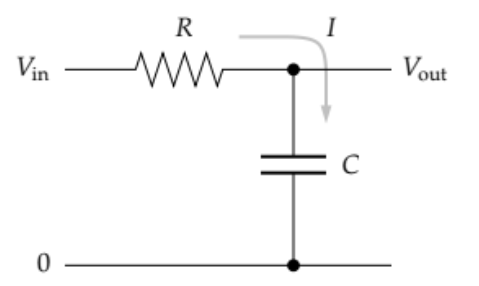

Usando la **ley de Ohm**, la ley de capacitor y suponiendo que la carga de salida tiene una impedancia muy alta, de modo que una cantidad insignificante de corriente fluye a traves de ella, es posible escribir las ecuaciones que gobiernan el circuito de la siguiente manera. Sea $I$ la corriente que fluye a traves de $R$ y dentro del capacitor, y sea $Q$ la carga en el capacitor. Entonces:

\begin{align}
    &IR = V_{in} - V_{out}\\
    &Q = C V_{out}\\
    &I = \frac{dQ}{dT}
\end{align}

Sustituyendo la segunda ecuacion en la tercera y luego sustituyendo el resultado en la primera ecuacion; encontramos que  $V_{in} − V_{out} = RC$ $(dV_{out}/dt)$, o equivalentemente:

\begin{align}
    \frac{dV_{out}}{dt}  = \frac{1}{RC}(V_{in} - V_{out})
\end{align}


**a)** Escribe un programa (o modifica algunos de los vistos en clase) para resolver esta ecuacion para  $V_{out}(t)$ usando

1. el metodo de Euler y
2. el metodo de Runge-Kutta de cuarto orden

cuando la señal de entrada es una onda cuadrada con frecuencia 1 y amplitud 1:

\begin{align}
    V_{in}(t) = 
    \begin{cases}
        1, \text{  si ⌊2t⌋ es par}\\
        -1, \text{  si ⌊2t⌋ es inpar}
    \end{cases}
\end{align}

donde $⌊x⌋$ significa $x$ redondeado hacia abajo al siguiente entero mas bajo. Utiliza el programa para graficar la salida del circuito del filtro desde $t = 0$ hasta $t = 10$ cuando $RC = 0,01, 0,1$ y $1$, con la condicion inicial $V_{out}(0) = 0$. Tendras que tomar una decision sobre que valor de  $h$ usar para tu calculo. Los valores pequenos dan resultados mas precisos, pero el programa tardara mas en ejecutarse.


In [263]:
#definimos Funciones a utiliar
"""
ese *args es simplemente una forma de que la función de integración (Euler o RK4) 
pueda recibir parámetros adicionales que necesita la ecuación diferencial, sin tener que fijarlos dentro de la función.
"""
def Euler(f,x0,t0,tf,dt,*args):
    T = [t0]
    X = [x0]

    t = t0
    x = x0

    while t < tf:
        x = x + f(t, x, *args) * dt
        t = t + dt
        X.append(x)
        T.append(t)

    return np.array(T), np.array(X)

def RK4(f,x0,t0,tf,dt, *args):
    T = [t0]
    X = [x0]

    t = t0
    x = np.array(x0, dtype=float)

    while t < tf:
        k1 = f(t, x, *args)
        k2 = f(t + dt*0.5, x + dt*k1*0.5, *args)
        k3 = f(t + dt*0.5, x + dt*k2*0.5, *args)
        k4 = f(t + dt, x + dt*k3, *args)

        x = x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        t += dt

        X.append(x)
        T.append(t)

    return np.array(T), np.array(X)


#definimos como funcion la ecuacion de la ley de Ohm
def f_RC(t, Vout, R, C):
    return (Vin(t) - Vout) / (R * C)

#definimos como funcion la señal cuadrada
def Vin(t):
    # ⌊2t⌋ es par -> 1, impar -> -1
    return 1 if int(np.floor(2*t)) % 2 == 0 else -1

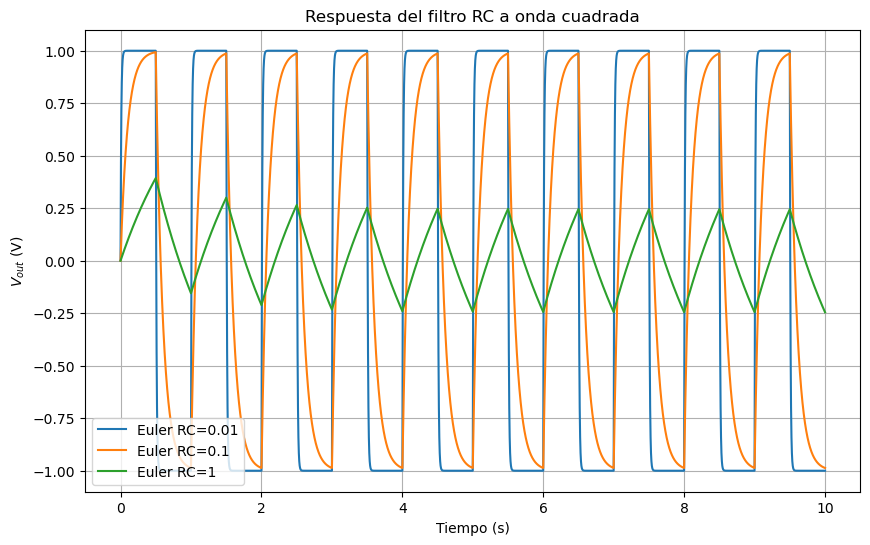

In [165]:
RC_valores = [0.01, 0.1, 1]
dt = 0.001
t0, tf = 0, 10

plt.figure(figsize=(10,6))

R = 1  # Ω

for RC in RC_valores:
    C = RC / R

    # Euler
    T_e, X_e = Euler(f_RC, 0, t0, tf, dt, R, C)

    plt.plot(T_e, X_e, '-', label=f'Euler RC={RC}')

plt.xlabel('Tiempo (s)')
plt.ylabel('$V_{out}$ (V)')
plt.title('Respuesta del filtro RC a onda cuadrada')
plt.grid(True)
plt.legend()
plt.show()

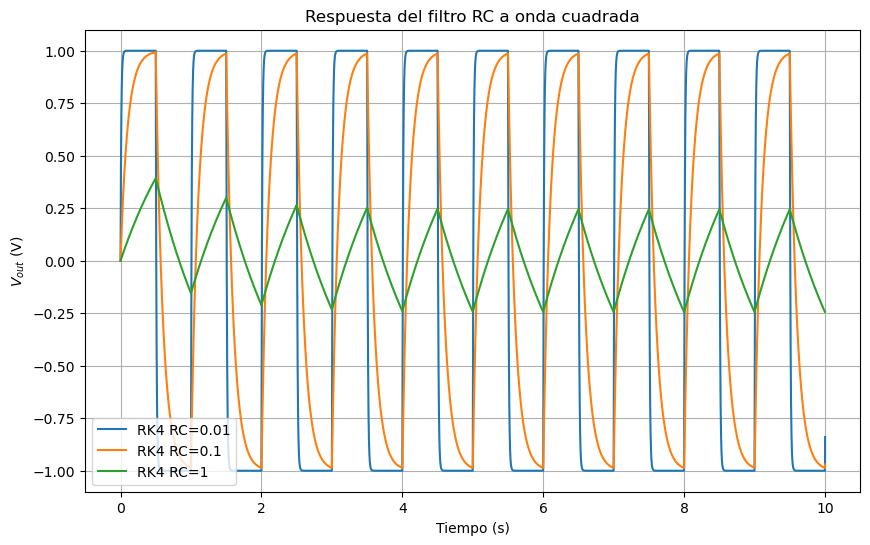

In [167]:
plt.figure(figsize=(10,6))

for RC in RC_valores:
    C = RC / R
    # RK4
    T_rk, X_rk = RK4(f_RC, 0, t0, tf, dt, R, C)
    plt.plot(T_rk, X_rk, '-', label=f'RK4 RC={RC}')

plt.xlabel('Tiempo (s)')
plt.ylabel('$V_{out}$ (V)')
plt.title('Respuesta del filtro RC a onda cuadrada')
plt.grid(True)
plt.legend()
plt.show()

**b)** Con base en las graficas producidas por tu programa, describe lo que ves y explica que esta haciendo el circuito.

Lo que puedo observar del comportamiento de este circuito es que se esta amortiguando la fecuencia de la señal, ya que al colocar una reciestencia estamoos generado un punto de acumulacion de carga que despues es utilizado para cargar de manera mas lenta el capasitor colocado en serie. Este permite que la señal no tenga cambios tan bruscos en el voltaje, podemos ver que para los 3 valores de RC = N, podemos ver un amortiguamiento que va de menor a mayor intencidad. Sin embargo para el caso RC= 1 podemos ver que hay una perdida significativa en el voltaje 

**c)** Describe brevemente como se compara (es decir cuales son las mayores diferencias, si es que las hay), al resolver el sistema. con el metodo de Euler y el de RungeKutta

Euler hace 1 evaluación de la función $f(t,x)$ por paso, mientras que RK4 hace 4 evaluaciones por paso.

Aunque RK4 cuesta más por paso, al necesitar menos pasos para la misma precisión, muchas veces es más eficiente en la práctica.

## 4. El modelo de Lotka-Volterra (predador-presa)

Como vimos en clase, un caso particular del modelo de Lotka-Volterra son un las ecuaciones de interacciones **depredador-presa** entre especies dos biologicas. Sean las variables $x$ e $y$ proporcionales al tamano de las poblaciones de dos especies, tradicionalmente llamadas "conejos” (la presa) y “zorros” (los depredadores). Se puede pensar que $x$ y $y$ son la poblacion en miles, digamos, de modo que $x = 2$
significa que hay $2000$ conejos. Estrictamente, los unicos valores permitidos de  $x$ y $y$ ser ́ıan multiplos de $0,001$, ya que solo se puede tener numeros enteros de conejos o zorros. Pero $0,001$ es un espacio de valores bastante cercano, por lo que es una aproximacion decente tratar  $x$ e $y$ como numeros reales continuos siempre que ninguno se acerque mucho a cero.

Ası, en el modelo de Lotka-Volterra **(predador-presa)**, los conejos se reproducen a un ritmo proporcional a su poblacion, pero los zorros se los comen a un ritmo proporcional tanto a su propia poblacion como a la poblacion de zorros, es decir:

\begin{align}
    \frac{dx}{dt} = \alpha x - \beta xy
\end{align}

donde $\alpha$ y $\beta$ son constantes. Al mismo tiempo, los zorros se reproducen a un ritmoproporcional al ritmo al que comen conejos, porque necesitan alimento para crecer y reproducirse, pero tambien mueren de viejos a un ritmo proporcional a su propia  ́
poblacion:

\begin{align}
    \frac{dy}{dt} =  \gamma xy - \delta x 
\end{align}

donde $\gamma$ y $\delta$ tambien son constantes.

**a)** Escribe un programa para resolver estas ecuaciones usando

1. el metodo de Euler y
2. el metodo de Runge-Kutta de cuarto orden

para el caso $\alpha = 1, \beta = \gamma = 0,5$ y $\delta = 2$, comenzando desde la condicion inicial $x = y = 2$.

In [88]:
#Parámetros  
alpha = 1.0
beta  = 0.5
gamma = 0.5
delta = 2.0

x0 = [2.0, 2.0]   # x(0)=2 (presas), y(0)=2 (depredadores)
t0, tf = 0.0, 30.0
dt = 0.01

def lotka_volterra(t, XY, alpha, beta, gamma, delta):
    x, y = XY[0], XY[1]
    dxdt = alpha*x - beta*x*y
    dydt = gamma*x*y - delta*y
    return np.array([dxdt, dydt])

In [94]:
# ===== Simulación =====
T_e,X_e  = Euler(lotka_volterra, x0, t0, tf, dt, alpha, beta, gamma, delta)
T_rk, X_rk = RK4(lotka_volterra, x0, t0, tf, dt, alpha, beta, gamma, delta)

# ===== Extraer poblaciones =====
x_e, y_e = X_e[:,0], X_e[:,1]
x_rk, y_rk = X_rk[:,0], X_rk[:,1]

print(x_e, y_e)
print(x_rk, y_rk)

[2.         2.         2.0002     ... 3.77993608 3.80881286 3.83792013] [2.         1.98       1.9602     ... 0.47210233 0.47158287 0.47113206]
[2.         2.00009967 2.00039737 ... 5.35693668 5.38819549 5.41947884] [2.         1.9801     1.96039995 ... 0.83349552 0.83923532 0.84514678]


**b)** Haz que el programa realice graficas que muestren

1. el espacio fase del sistema ((i.e. $x$ vs $y$) y tambien
2. en un grafico diferente  $x$ e $y$ como funcion del tiempo en los mismos ejes desde $t = 0$ hasta $t = 30$.

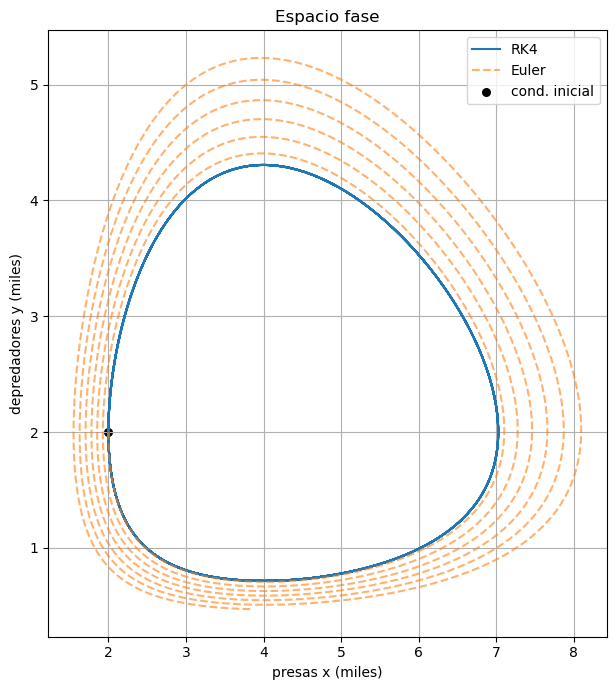

In [150]:
#Espacio Face
plt.figure(figsize=(12,7))

plt.subplot(1,2,2)
plt.plot(x_rk, y_rk, '-', label='RK4')
plt.plot(x_e,  y_e,  '--', label='Euler', alpha=0.6)
plt.scatter([x0[0]], [x0[1]], color='k', s=30, label='cond. inicial')
plt.xlabel('presas x (miles)')
plt.ylabel('depredadores y (miles)')
plt.title('Espacio fase')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (10002,) and (3001,)

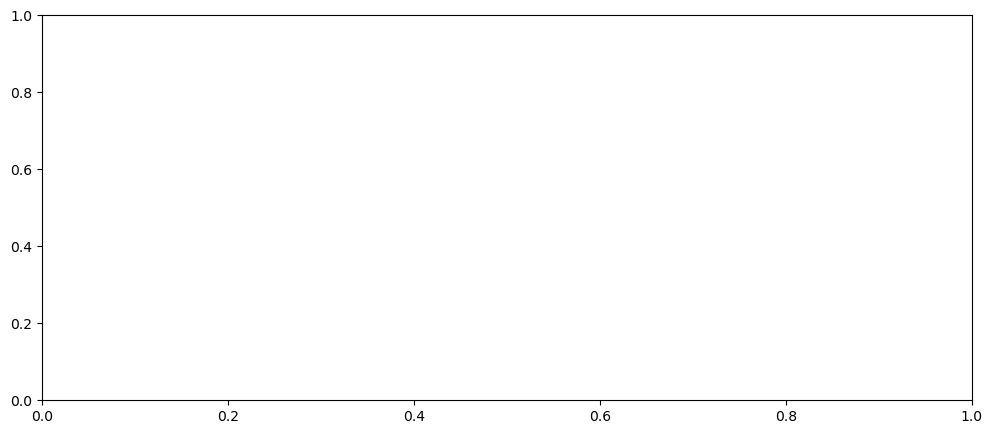

In [152]:
plt.figure(figsize=(12,5))

plt.plot(T_e,  x_e,  '--', label='presas (x) Euler', alpha=0.6)
plt.plot(T_e,  y_e,  '--', label='depredadores (y) Euler', alpha=0.6)

plt.xlabel('t')
plt.ylabel('Población (miles)')
plt.title('Series temporales')
plt.legend()
plt.grid(True)

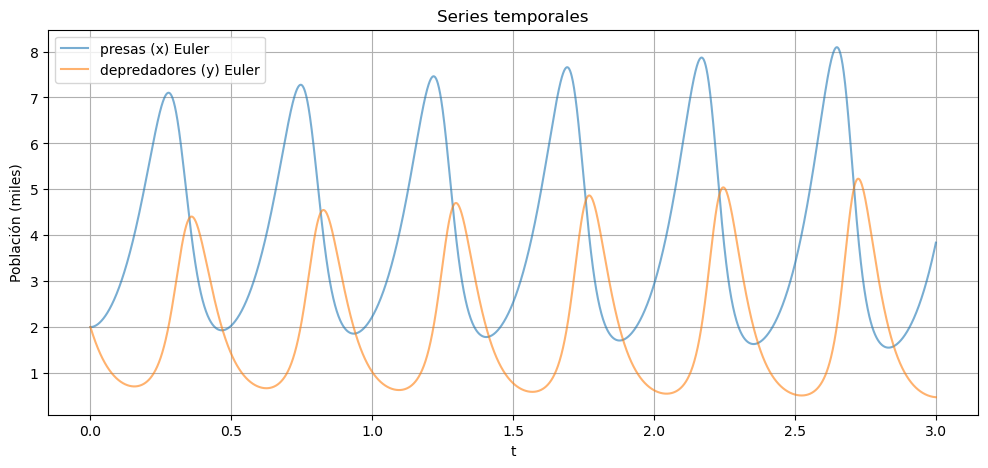

In [160]:
#Aqui si pedi ayuda de la ia de jupyter por que esta selda de arriba si corria bien y luego ya no :c

T_e_truncated = T_e[:3001]  # Assuming T_e is the longer array with 10002 elements

plt.figure(figsize=(12,5))

# Use the truncated array for plotting
plt.plot(T_e_truncated, x_e, '-', label='presas (x) Euler', alpha=0.6)
plt.plot(T_e_truncated, y_e, '-', label='depredadores (y) Euler', alpha=0.6)

plt.xlabel('t')
plt.ylabel('Población (miles)')
plt.title('Series temporales')
plt.legend()
plt.grid(True)

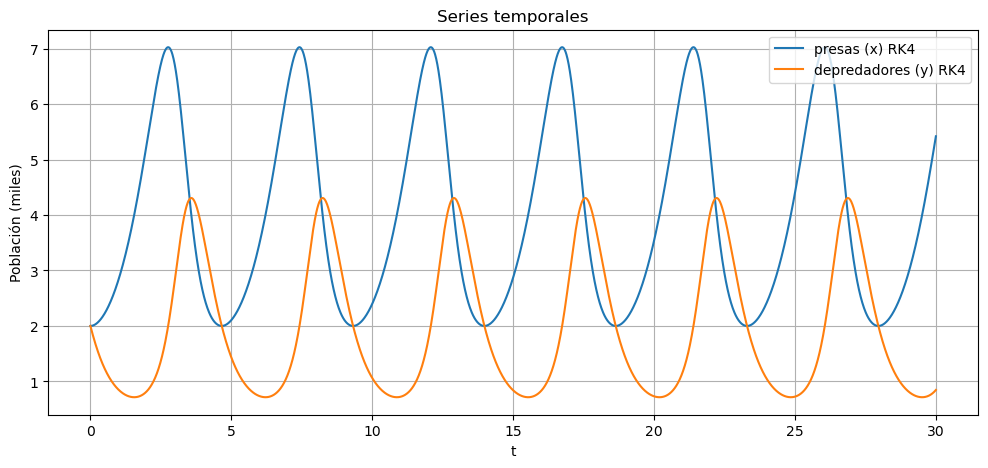

In [148]:
# ===== Gráficas =====
plt.figure(figsize=(12,5))



plt.plot(T_rk, x_rk, label='presas (x) RK4')
plt.plot(T_rk, y_rk, label='depredadores (y) RK4')
plt.xlabel('t')
plt.ylabel('Población (miles)')
plt.title('Series temporales')
plt.legend()
plt.grid(True)

**c)** Describe con tus propias palabras lo que esta sucediendo en el sistema, en terminos de presas y depredadores.

Lo que puedo observar en el comportamiento de la grafica de tiempo contra densidad poblacional de las especies es que,
las poblaciones estan inversamente proporcional relacionadas con la tasa de cambio una de la otra. MIentras que la poblacion de presas sea baja propicia a que la poblacion de depredadores comience a disminuir. En cuanto hay un crecimimiento de poblacion de conejos aproximadamente 4 mil en las presas, podemos  ver como la poblacion de predadores comienza a crecer hasta el punto en el que la poblacion es tan grande que la de presas comienza a disminur.

**d)** Describe brevemente como se compara resolver el sistema con el metodo de Euler y el de Runge-Kutta.

En el ciclo de tiempo, se puede notar como se hace mas grande la amplitud de de la poblacion con el metodo de Euler, porque justamente el metodo es de primer orden paraxial, y el error está relacionado por un término proporcional al valor de los saltos de h

En cambio Runge-Kutta lo mantiene constante con una aproximacion mas fina.

## 5. Las ecuaciones de Lorenz

Uno de los conjuntos de ecuaciones diferenciales mas famosos en el estudio de los sistemas dinamicos y los sistemas complejos son las ecuaciones de Lorenz:

\begin{align}
    \frac{dx}{dt} &=  \sigma (y-x), \\
    \frac{dy}{dt} &=  rx - y - xz, \\
    \frac{dz}{dt} &=  xy - bz, 
\end{align}

donde $\sigma, r$ y $b$ son constantes. (Los nombres $\sigma, r$ y $b$ son extranos, pero tradicionales; siempre se usan en estas ecuaciones por razones historicas). Estas ecuaciones fueron estudiadas por primera vez por Edward Lorenz en $1963$, quien las derivo de un modelo simplificado de patrones climaticos. La razon de su fama es que fueron uno de los primeros ejemplos incontrovertibles de caos determinista, la ocurrencia de movimiento aparentemente aleatorio aunque no haya aleatoriedad incorporada en las ecuaciones. Otro ejemplo de caos es el mapeo logıstico que vimos anteriormente en el curso.

**a)** Escribe un programa para resolver las ecuaciones de Lorenz para el caso $\sigma = 10, r = 28$ y $b = 8/3$ en el rango de $t \in (0, 50)$ con condicion inicial $(x, y, z) = (0, 1, 0)$ (puedes ampliar tus programas anteriores de los metodos Euler y/o Runge-Kutta).

In [210]:
Sig = 10
Erre = 28
Be = 8/3

dt = 0.01
T0 = 0.0 #Periodo temporal
Tf = 50.0

CI = [0,1,0] #Condicion inicial


def Lorenz(X0, *args):
    S, R, B = args  # desempaquetamos parámetros extra
    x, y, z = X0

    dxdt = S*(y - x)
    dydt = R*x - y - x*z
    dzdt = x*y - B*z

    return np.array([dxdt, dydt, dzdt])

"""
Tenia problemas para pasarle los parametros a la funcion de RK4  
asi que la redefini para que pueda tener cualquier parametro arbitrario de la funcion a Iteraar
"""
def RK4(f, X0, t0, tf, dt, *args):
    t = np.arange(t0, tf+dt, dt)
    X = np.zeros((len(t), len(X0)))
    X[0] = X0

    for i in range(len(t)-1):
        k1 = f(X[i], *args)
        k2 = f(X[i] + dt*k1/2, *args)
        k3 = f(X[i] + dt*k2/2, *args)
        k4 = f(X[i] + dt*k3, *args)

        X[i+1] = X[i] + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

    return t, X

In [214]:
T1, X1 = RK4(Lorenz, CI, T0, Tf, dt, Sig, Erre, Be)
print(T1,X1)

[0.000e+00 1.000e-02 2.000e-02 ... 4.998e+01 4.999e+01 5.000e+01] [[0.00000000e+00 1.00000000e+00 0.00000000e+00]
 [9.51213689e-02 1.00353674e+00 4.79006302e-04]
 [1.82772266e-01 1.03241908e+00 1.86843036e-03]
 ...
 [7.96217296e+00 1.04827346e+01 2.31143352e+01]
 [8.21563634e+00 1.07622267e+01 2.33541970e+01]
 [8.47101306e+00 1.10293066e+01 2.36369608e+01]]


**b)** Haz que tu programa muestre una grafica de  $y$ en funcion del tiempo. Ten en cuenta la naturaleza impredecible del movimiento. 

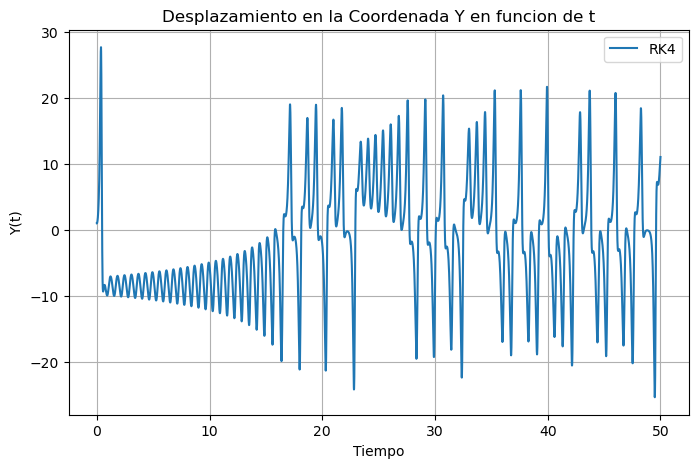

In [235]:
plt.figure(figsize=(8,5))
plt.plot(T1, X1[:,1], label="RK4")
plt.xlabel("Tiempo")
plt.ylabel("Y(t)")
plt.title("Desplazamiento en la Coordenada Y en funcion de t")
plt.legend()
plt.grid(True)
plt.show()

**c)** Haz que tu programa tambien muestre una grafica de  ́$z$ contra $x$. Deberıas de ver una imagen del famoso “atractor extraño” de las ecuaciones de Lorenz (que tambien vimos en clase), un diagrama desequilibrado en forma de mariposa que nunca se repite.

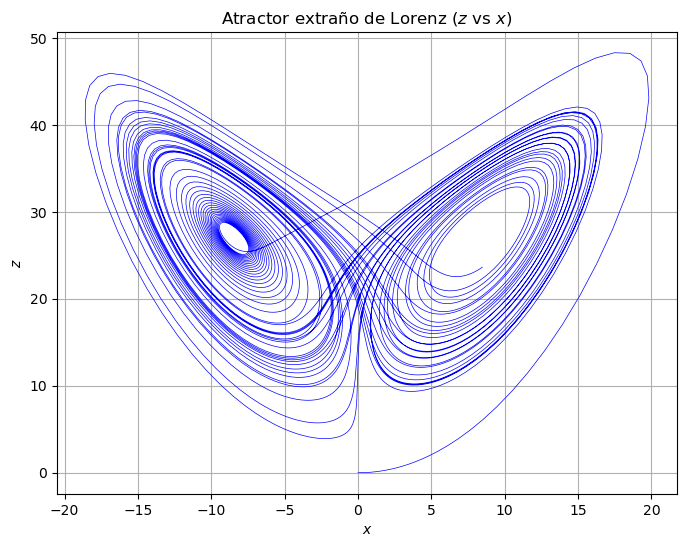

In [231]:
plt.figure(figsize=(8,6))
plt.plot(X1[:,0], X1[:,2], color="blue", linewidth=0.5)
plt.xlabel("$x$")
plt.ylabel("$z$")
plt.title("Atractor extraño de Lorenz ($z$ vs $x$)")
plt.grid(True)
plt.show()

# 6. El pendulo simple 

Considere un pendulo con un brazo de longitud  $l$ que sostiene una masa con valor $m$: 

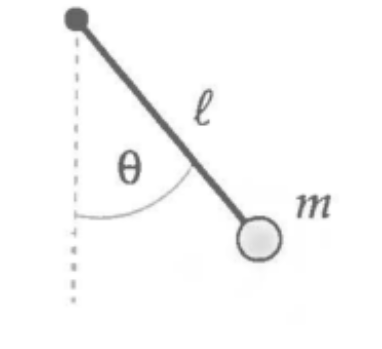

En terminos del  angulo  $\theta$ de desplazamiento del brazo respecto de la vertical, la aceleracion de la masa es  ́$\displaystyle{l \frac{d^2 \theta}{dt^2}}$ en la direccion tangencial. Mientras tanto, la fuerza sobre la masa (el peso) es en direccion vertical hacia abajo y con magnitud  ́ mg, donde $g = 9.81ms^{−2}$ es la aceleracion debida a la gravedad y (por simplicidad) ignoraremos la friccion y asumiremos que el brazo no tiene masa. La componente de esta fuerza en la direccion tangencial es  $mg sen\theta$, siempre hacia el punto de reposo en $\theta = 0$ y, por tanto, la segunda ley de Newton nos da una ecuacion de movimiento para el pendulo de la forma:

\begin{align}
    \frac{d^2 \theta}{dt^2} = - \frac{g}{l} Sen \theta
\end{align}

Como vimos, en clase, dado que esta ecuacion es no lineal, a  un no es posible resolver esta ecuacion analıticamente y no se conoce una solucion exacta. Sin embargo, podemos resolverla con la computadora de manera sencilla. Usando el truco visto en clase (para convertir una ecuacion de segundo orden, en dos ecuaciones de primer orden); definimos una nueva variable $\omega$ como:

\begin{align}
    \frac{d \theta}{dt} = \omega
\end{align}

Entonces la ecuacion de nuestro sistema se convierte en 

\begin{align}
    \frac{d \omega}{dt} = - \frac{g}{l} Sen \theta
\end{align}

De esta forma, tenemos un sistema de dos ecuaciones de primer orden, que es equivalente a la ecuacion de segundo orden con la que comenzamos. Al combinar las dos variables θ y ω en un solo vector $\vec{r} = (\theta, \omega)$ es posible resolver las dos ecuaciones
simultaneamente, usando uno de los metodos que hemos visto, para dos dimensiones. 

\begin{align}
    \frac{d \vec{r}}{dt} = f(\vec{r},t)
\end{align}

**a)** Escribe un programa para resolver el sistema, usando el metodo de Runge-Kutta de cuarto orden para un pendulo con un brazo de $l = 10 [cm]$.

In [273]:
"""
Esta es la funcion definida en clase 
"""
def OsciladorSimple(x):  # x es un vector en 2D  (x,v)
    w0 = 1
    y = np.array(np.zeros(2))
    
    y[0] = x[1]
    y[1] = -w0*x[0]

    return y

"""
Este es el buenazo
"""

def PNL(x): #Pendulo no lineal
    g = 9.81  
    L = 0.1  # longitud en [m]
    y = np.array(np.zeros(2))
    y[0] = x[1]                   # d(theta)/dt = omega
    y[1] = -(g/L) * np.sin(x[0])  # d(omega)/dt = -(g/L) Sen(theta)
    return y

def RK4_2D(f,x0,t0,tf,dt):
    T = [t0]
    X1 = [x0[0]]
    X2 = [x0[1]]

    t = t0
    x = np.array(x0, dtype=float)

    while t < tf: #Esta es una funcion autónoma entonces no evaluamos el tiempo aqui
        k1 = f(x)
        k2 = f(x + 0.5*dt*k1)
        k3 = f(x + 0.5*dt*k2)
        k4 = f(x + dt*k3)

        x = x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        t += dt

        X1.append(x[0])
        X2.append(x[1])
        T.append(t)

    return np.array(X1), np.array(X2), np.array(T)

In [271]:
# Condiciones iniciales
theta0 = np.pi/3  # 60 grados
omega0 = 0        # en reposo
x0 = [theta0, omega0]
t0 = 0
tf = 10
dt = 0.01

# Resolver
Theta, Omega, T = RK4_2D(PNL,x0, t0, tf, dt)

print(Theta, Omega)

[ 1.04719755  1.04295144  1.03023407 ... -0.49096773 -0.40222475
 -0.30964702] [ 0.         -0.84887448 -1.69354119 ...  8.65582819  9.07969369
  9.42168051]


**b)** Usa tu programa para mostrar en una sola figura

1. la grafica del espacio fase del sistema ($\theta$ vs $\omega$) para varias condiciones iniciales del angulo $(\theta_0)$ y
2. el campo de pendientes.

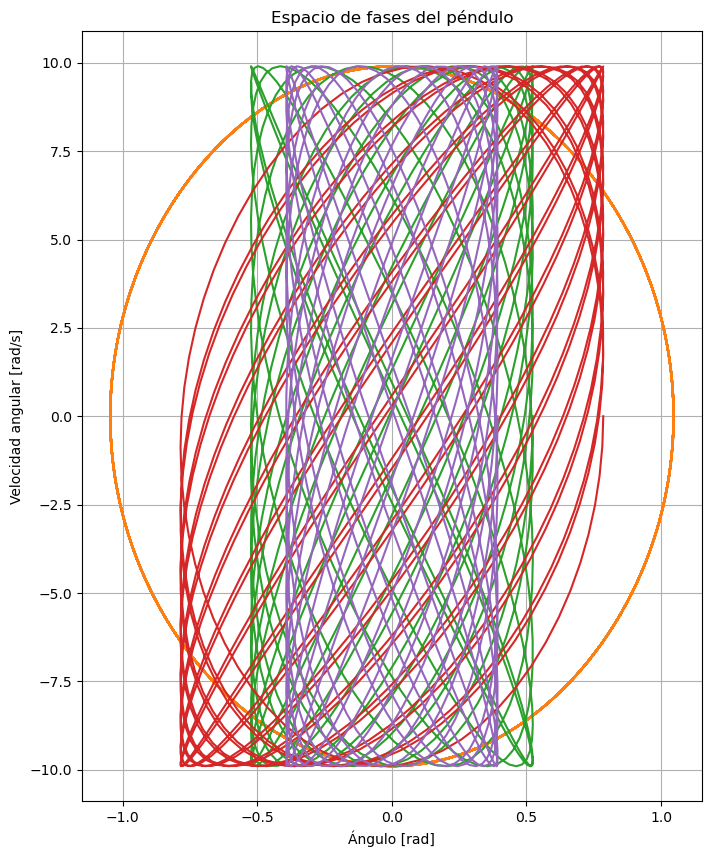

In [311]:
theta2 = np.pi/3
theta3 = np.pi/6
theta4 = np.pi/4
theta5 = np.pi/8

x2 = [theta2, omega0]
x3 = [theta3, omega0]
x4 = [theta4, omega0]
x5 = [theta5, omega0]

Theta2, Omega2, T2 = RK4_2D(PNL,x2, t0, tf, dt)
Theta3, Omega3, T3 = RK4_2D(PNL,x3, t0, tf, dt)
Theta4, Omega4, T4 = RK4_2D(PNL,x4, t0, tf, dt)
Theta5, Omega5, T5 = RK4_2D(PNL,x5, t0, tf, dt)



plt.figure(figsize=(8,10))
plt.plot(Theta, Omega)
plt.plot(Theta2, Omega)
plt.plot(Theta3, Omega)
plt.plot(Theta4, Omega)
plt.plot(Theta5, Omega)
plt.xlabel("Ángulo [rad]")
plt.ylabel("Velocidad angular [rad/s]")
plt.grid(True)
plt.title("Espacio de fases del péndulo")
plt.show()

**c)** Usa el programa para graficar $\theta$ en funcion del tiempo, para varias condiciones iniciales (en el mismo grafico).

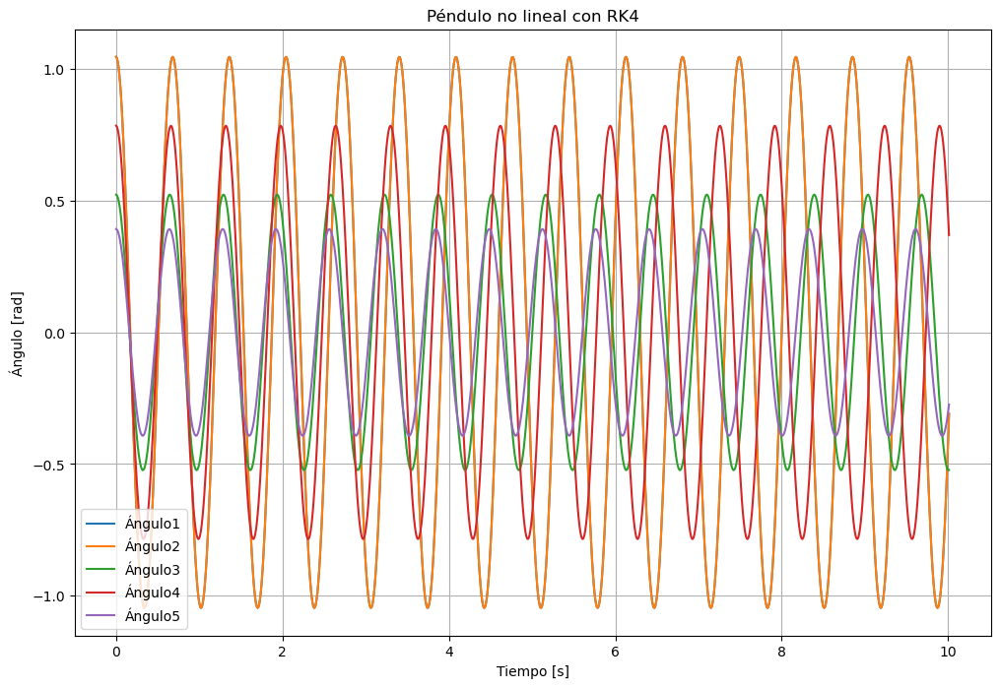

In [289]:
plt.figure(figsize=(12,8))
plt.plot(T, Theta, label="Ángulo1")
plt.plot(T, Theta2, label="Ángulo2")
plt.plot(T, Theta3, label="Ángulo3")
plt.plot(T, Theta4, label="Ángulo4")
plt.plot(T, Theta5, label="Ángulo5")
plt.xlabel("Tiempo [s]")
plt.ylabel("Ángulo [rad]")
plt.grid(True)
plt.legend()
plt.title("Péndulo no lineal con RK4")
plt.show()

**d)** Describe con tus propias palabras lo que esta sucediendo en el sistema.

Yo esperaba que no hubiera desface alguno ya que estabmos despreciando la friccion en el sistema, pero puedo observar como los puntos en los que las posiciones coincidian en un tiempo especifico se van desplazando mientras mas iteraciones tenemos en el tiempo. 